In [33]:
import numpy as np
from numpy.random import seed

import matplotlib.pyplot as plt
import matplotlib as mpl

import cell_cycle_model as model
import plotting as plot
from model_utils import build_parameters
from model_utils import run_model
from model_utils import order_parameter

mpl.rcParams['pdf.fonttype']   = 42 

# Single run example:

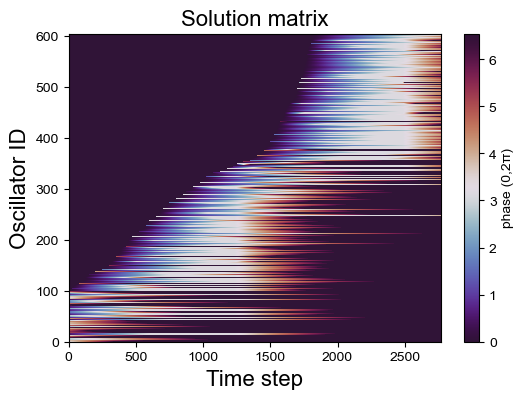

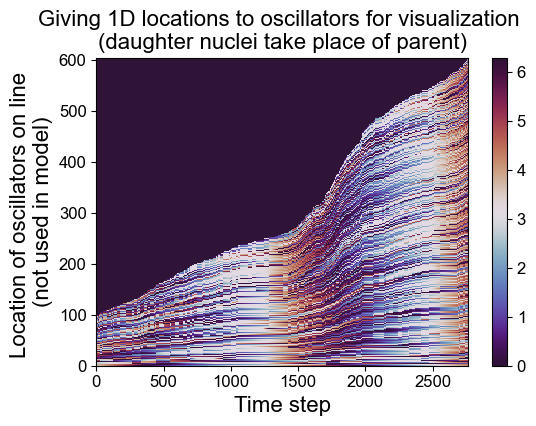

In [2]:
seed(0)
start_N = 100
N = 1000 #number of oscillators to exist total, not final N

options = {
    'tip_splits': 'random',
    'frequencies': 'G1_exit',
}

params = build_parameters(start_N, N, options, omega_mean=120, escape_rate=0.005) # (escape rate = lambda parameter)

L, theta, t, order_all_t, end_simulation, num_splits_t, split_times, influx_idx = \
    model.solve(start_N, N, params, options)

fig, ax = plot.solution_matrix(theta, order_all_t)
fig, ax = plot.plot_phases(theta, t, order_all_t)

# Figure 3E:

In [3]:
config = {
    'seeds': 50,
    'loop_type': 'startN',
    'loop_values': [40, 60, 80, 100],
    'options': {
        ###############################
        'tip_splits': 'random',
        # 'tip_splits': 'all_random',
        # 'tip_splits': 'triggered',
        ###############################
        'frequencies': 'random',
        # 'frequencies': 'G1_exit',
        ###############################
        ### optional, include to override defaults:
        # 'N': 5000,         # default: 8000
        # 'D': 0.02,         # default: 0
        # 'w_std': 0,        # default: 40
        # 'w_mean': 110,     # default: 120
        # 'lambda': 0.05,    # default 0.05
        # 'beta': 0.03,      # default 0.03
    }
}

data = run_model(config, save_as='fig3.pkl')

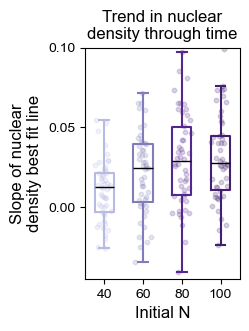

In [4]:
plot.vary_N(name='fig3', panels='EH', slope_y_lim=0.1, just_slopes=True)

# SI Figure 2:

## B:

In [5]:
config = {
    'seeds': 50,
    'loop_type': 'startN',
    'loop_values': [40, 60, 80, 100],
    'options': {
        ###############################
        'tip_splits': 'random',
        # 'tip_splits': 'all_random',
        # 'tip_splits': 'triggered',
        ###############################
        'frequencies': 'random',
        # 'frequencies': 'G1_exit',
        ###############################
        ### optional, include to override defaults:
        # 'N': 5000,         # default: 8000
        'D': 0.02,         # default: 0
        'w_std': 0,        # default: 40
        # 'w_mean': 110,     # default: 120
        # 'lambda': 0.05,    # default 0.05
        # 'beta': 0.03,      # default 0.03
    }
}

data = run_model(config, save_as='sfig2a.pkl')

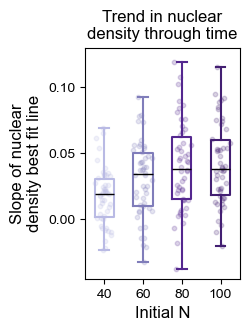

In [6]:
plot.vary_N('sfig2a', 'A', 0.13, True)

## D:

In [7]:
config = {
    'seeds': 50,
    'loop_type': 'startN',
    'loop_values': [40, 60, 80, 100],
    'options': {
        ###############################
        # 'tip_splits': 'random',
        'tip_splits': 'all_random',
        # 'tip_splits': 'triggered',
        ###############################
        'frequencies': 'random',
        # 'frequencies': 'G1_exit',
        ###############################
        ### optional, include to override defaults:
        # 'N': 5000,         # default: 8000
        # 'D': 0.02,         # default: 0
        # 'w_std': 0,        # default: 40
        # 'w_mean': 110,     # default: 120
        # 'lambda': 0.05,    # default 0.05
        # 'beta': 0.03,      # default 0.03
    }
}

data = run_model(config, save_as='sfig2b.pkl')

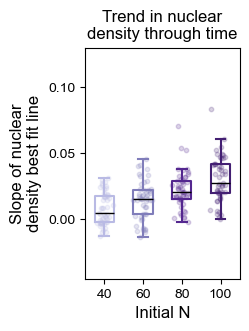

In [8]:
plot.vary_N('sfig2b', 'B', 0.13, True)

# Figure 4E-H:

In [9]:
config = {
    'seeds': 50,
    'loop_type': 'escape_rate',
    'loop_values': [5, 0.5, 0.05, 0.005],
    'options': {
        ###############################
        'tip_splits': 'random',
        # 'tip_splits': 'all_random',
        # 'tip_splits': 'triggered',
        ###############################
        # 'frequencies': 'random',
        'frequencies': 'G1_exit',
        ###############################
        ### optional, include to override defaults:
        # 'N': 5000,         # default: 8000
        # 'D': 0.02,         # default: 0
        # 'w_std': 0,        # default: 40
        # 'w_mean': 110,     # default: 120
        # 'lambda': 0.05,    # default 0.05
        # 'beta': 0.03,      # default 0.03
    }
}

data = run_model(config, save_as='fig4.pkl')

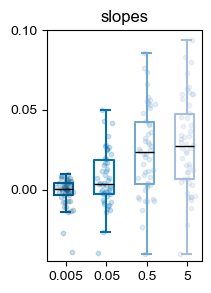

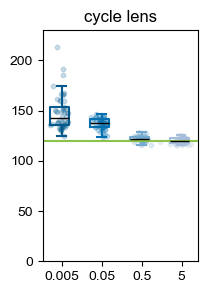

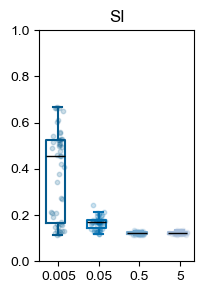

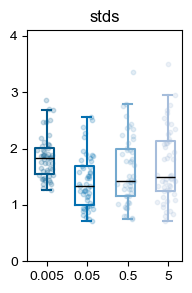

In [10]:
plot.vary_lambda('fig4', 'EH', 0.1)

# SI Figure 3:

(0.0, 1.0)

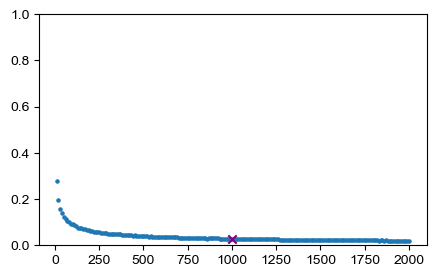

In [37]:
Ns = np.arange(10, 2001, 10)
seeds = 1000

rs = np.zeros((len(Ns), seeds))
for i, val in enumerate(Ns):
    for j in range(seeds): 
        rs[i,j] = order_parameter(np.random.uniform(0, 2*np.pi, val))

mean_rs = np.mean(rs, axis=1)
r_1000 = mean_rs[Ns == 1000][0]

plt.figure(figsize=(5,3))
plt.scatter(Ns, np.mean(rs, axis=1), s=5)
plt.scatter(1000, r_1000, c='purple', marker='x')
plt.ylim([0,1])

# SI Figure 4:

## A-C:

In [11]:
config = {
    'seeds': 50,
    'loop_type': 'omega_mean',
    'loop_values': [90, 100, 110, 120],
    'options': {
        ###############################
        'tip_splits': 'random',
        # 'tip_splits': 'all_random',
        # 'tip_splits': 'triggered',
        ###############################
        # 'frequencies': 'random',
        'frequencies': 'G1_exit',
        ###############################
        ### optional, include to override defaults:
        'N': 5000,         # default: 8000
        # 'D': 0.02,         # default: 0
        # 'w_std': 0,        # default: 40
        # 'w_mean': 110,     # default: 120
        'lambda': 0.05,    # default 0.05
        # 'beta': 0.03,      # default 0.03
    }
}

data = run_model(config, save_as='sfig4ac.pkl')

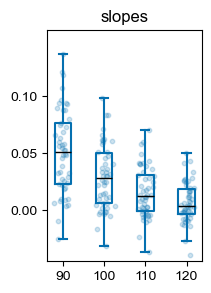

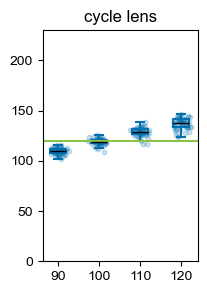

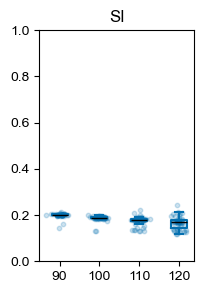

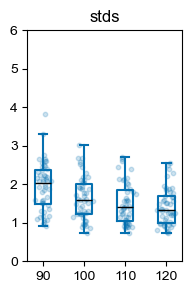

In [12]:
plot.vary_freqs('sfig4ac', 'AC', 0.158, [90, 100, 110, 120], 0.05)

## D-F:

In [13]:
config = {
    'seeds': 50,
    'loop_type': 'omega_mean',
    'loop_values': [30, 60, 90, 120],
    'options': {
        ###############################
        'tip_splits': 'random',
        # 'tip_splits': 'all_random',
        # 'tip_splits': 'triggered',
        ###############################
        # 'frequencies': 'random',
        'frequencies': 'G1_exit',
        ###############################
        ### optional, include to override defaults:
        'N': 5000,         # default: 8000
        # 'D': 0.02,         # default: 0
        # 'w_std': 0,        # default: 40
        # 'w_mean': 110,     # default: 120
        'lambda': 0.005,    # default 0.05
        # 'beta': 0.03,      # default 0.03
    }
}

data = run_model(config, save_as='sfig4df.pkl')

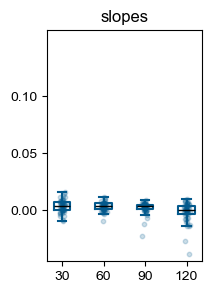

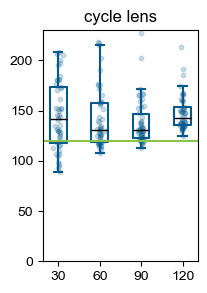

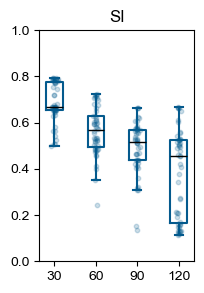

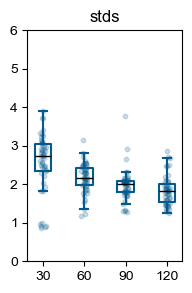

In [14]:
plot.vary_freqs('sfig4df', 'DF', 0.158, [30, 60, 90, 120], 0.005)

## G-I:

In [15]:
config = {
    'seeds': 50,
    'loop_type': 'omega_mean',
    'loop_values': [90, 100, 110, 120],
    'options': {
        ###############################
        # 'tip_splits': 'random',
        'tip_splits': 'all_random',
        # 'tip_splits': 'triggered',
        ###############################
        # 'frequencies': 'random',
        'frequencies': 'G1_exit',
        ###############################
        ### optional, include to override defaults:
        'N': 5000,         # default: 8000
        # 'D': 0.02,         # default: 0
        # 'w_std': 0,        # default: 40
        # 'w_mean': 110,     # default: 120
        'lambda': 0.05,    # default 0.05
        # 'beta': 0.03,      # default 0.03
    }
}

data = run_model(config, save_as='sfig4gi.pkl')

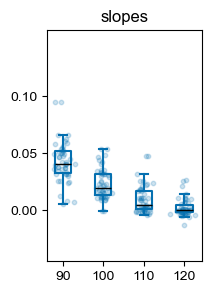

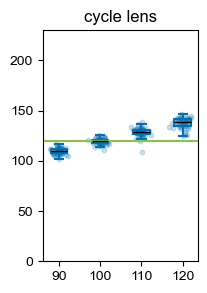

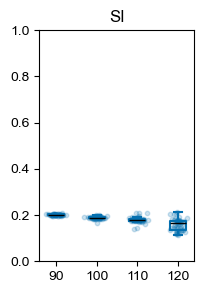

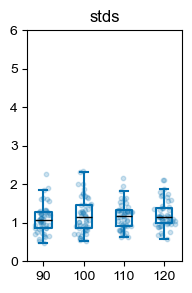

In [16]:
plot.vary_freqs('sfig4gi', 'GI', 0.158, [90, 100, 110, 120], 0.05)

## J-L

In [17]:
config = {
    'seeds': 50,
    'loop_type': 'omega_mean',
    'loop_values': [30, 60, 90, 120],
    'options': {
        ###############################
        # 'tip_splits': 'random',
        'tip_splits': 'all_random',
        # 'tip_splits': 'triggered',
        ###############################
        # 'frequencies': 'random',
        'frequencies': 'G1_exit',
        ###############################
        ### optional, include to override defaults:
        'N': 5000,         # default: 8000
        # 'D': 0.02,         # default: 0
        # 'w_std': 0,        # default: 40
        # 'w_mean': 110,     # default: 120
        'lambda': 0.005,    # default 0.05
        # 'beta': 0.03,      # default 0.03
    }
}

data = run_model(config, save_as='sfig4jl.pkl')

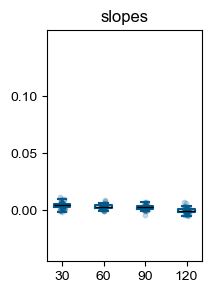

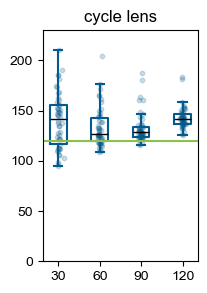

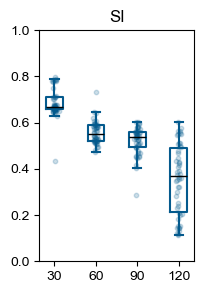

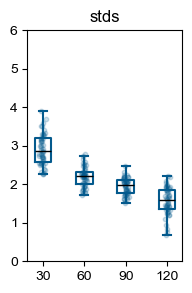

In [18]:
plot.vary_freqs('sfig4jl', 'JL', 0.158, [30, 60, 90, 120], 0.005)

# Figure 5:

## B-E:

In [19]:
config = {
    'seeds': 50,
    'loop_type': 'escape_rate',
    'loop_values': [5, 0.5, 0.05, 0.005],
    'options': {
        ###############################
        # 'tip_splits': 'random',
        # 'tip_splits': 'all_random',
        'tip_splits': 'triggered',
        ###############################
        # 'frequencies': 'random',
        'frequencies': 'G1_exit',
        ###############################
        ### optional, include to override defaults:
        # 'N': 5000,         # default: 8000
        # 'D': 0.02,         # default: 0
        # 'w_std': 0,        # default: 40
        # 'w_mean': 110,     # default: 120
        # 'lambda': 0.005,    # default 0.05
        'beta': 1,      # default 0.03
    }
}

data = run_model(config, save_as='fig5be.pkl')

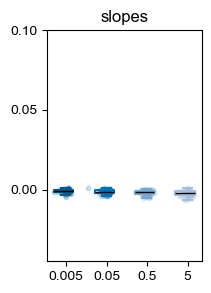

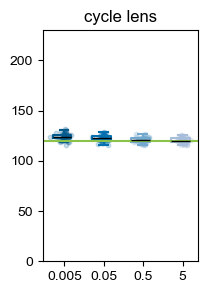

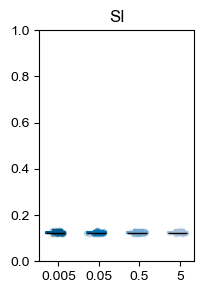

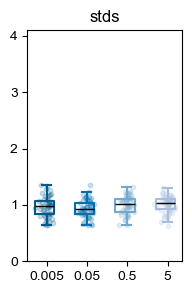

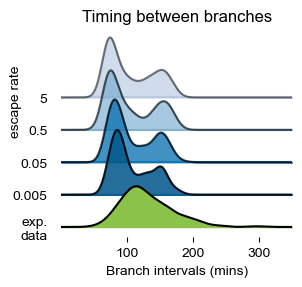

In [20]:
plot.vary_lambda('fig5be', 'BD', 0.1)
plot.ridge_plot('fig5be', 'E', 'lambda', 50)

## F-I:

In [21]:
config = {
    'seeds': 50,
    'loop_type': 'escape_rate',
    'loop_values': [5, 0.5, 0.05, 0.005],
    'options': {
        ###############################
        # 'tip_splits': 'random',
        # 'tip_splits': 'all_random',
        'tip_splits': 'triggered',
        ###############################
        # 'frequencies': 'random',
        'frequencies': 'G1_exit',
        ###############################
        ### optional, include to override defaults:
        # 'N': 5000,         # default: 8000
        # 'D': 0.02,         # default: 0
        # 'w_std': 0,        # default: 40
        # 'w_mean': 110,     # default: 120
        # 'lambda': 0.005,    # default 0.05
        'beta': 0.03,      # default 0.03
    }
}

data = run_model(config, save_as='fig5fi.pkl')

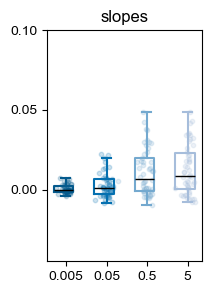

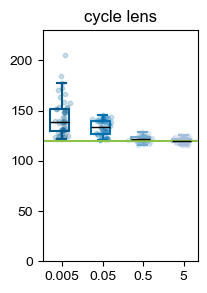

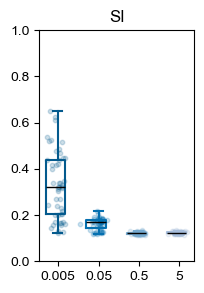

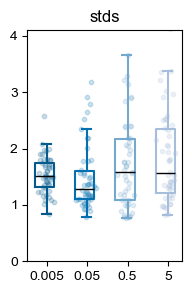

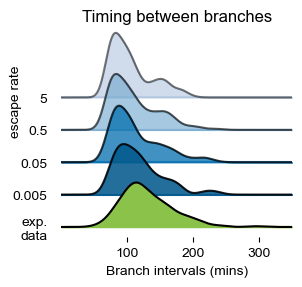

In [22]:
plot.vary_lambda('fig5fi', 'FH', 0.1)
plot.ridge_plot('fig5fi', 'I', 'lambda', 50)

## J-M:

In [23]:
config = {
    'seeds': 50,
    'loop_type': 'startN',
    'loop_values': [40, 60, 80, 100],
    'options': {
        ###############################
        # 'tip_splits': 'random',
        # 'tip_splits': 'all_random',
        'tip_splits': 'triggered',
        ###############################
        # 'frequencies': 'random',
        'frequencies': 'G1_exit',
        ###############################
        ### optional, include to override defaults:
        # 'N': 5000,         # default: 8000
        # 'D': 0.02,         # default: 0
        # 'w_std': 0,        # default: 40
        # 'w_mean': 110,     # default: 120
        # 'lambda': 0.005,    # default 0.05
        # 'beta': 0.03,      # default 0.03
    }
}

data = run_model(config, save_as='fig5jm.pkl')

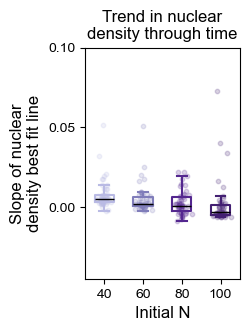

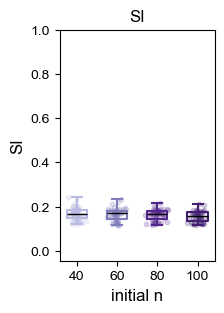

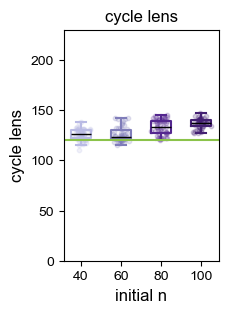

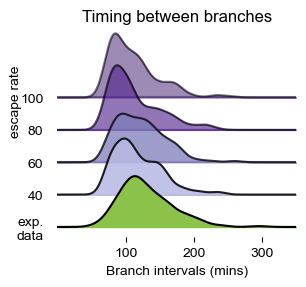

In [24]:
plot.vary_N('fig5jm', 'JL', 0.1, False)
plot.ridge_plot('fig5jm', 'M', 'N', 50)

# SI Figure 5:

## A-D is the same as Fig 5B-E

## E-H:

In [25]:
config = {
    'seeds': 50,
    'loop_type': 'escape_rate',
    'loop_values': [5, 0.5, 0.05, 0.005],
    'options': {
        ###############################
        # 'tip_splits': 'random',
        # 'tip_splits': 'all_random',
        'tip_splits': 'triggered',
        ###############################
        # 'frequencies': 'random',
        'frequencies': 'G1_exit',
        ###############################
        ### optional, include to override defaults:
        # 'N': 5000,         # default: 8000
        # 'D': 0.02,         # default: 0
        # 'w_std': 0,        # default: 40
        # 'w_mean': 110,     # default: 120
        # 'lambda': 0.005,    # default 0.05
        'beta': 0.06,      # default 0.03
    }
}

data = run_model(config, save_as='sfig5eh.pkl')

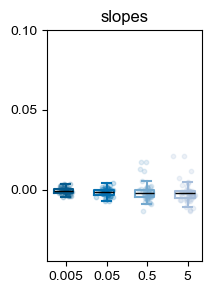

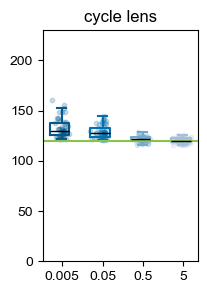

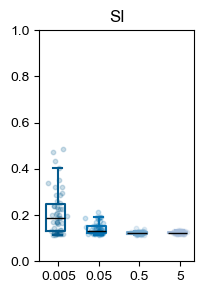

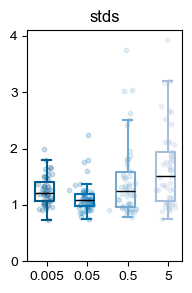

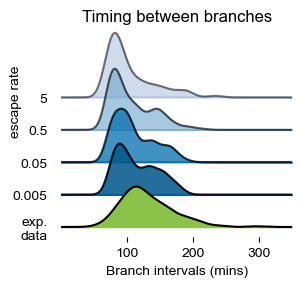

In [26]:
plot.vary_lambda('sfig5eh', 'EG', 0.1)
plot.ridge_plot('sfig5eh', 'H', 'lambda', 50)

## I-L same as Fig 5 F-I

## M-P:

In [27]:
config = {
    'seeds': 50,
    'loop_type': 'escape_rate',
    'loop_values': [5, 0.5, 0.05, 0.005],
    'options': {
        ###############################
        # 'tip_splits': 'random',
        # 'tip_splits': 'all_random',
        'tip_splits': 'triggered',
        ###############################
        # 'frequencies': 'random',
        'frequencies': 'G1_exit',
        ###############################
        ### optional, include to override defaults:
        # 'N': 5000,         # default: 8000
        # 'D': 0.02,         # default: 0
        # 'w_std': 0,        # default: 40
        # 'w_mean': 110,     # default: 120
        # 'lambda': 0.005,    # default 0.05
        'beta': 0.02,      # default 0.03
    }
}

data = run_model(config, save_as='sfig5mp.pkl')

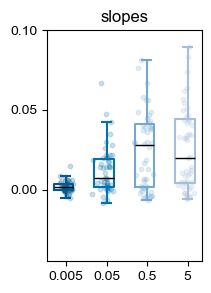

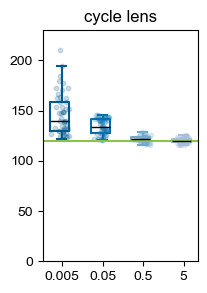

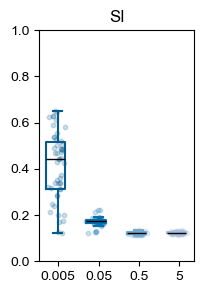

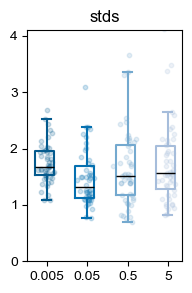

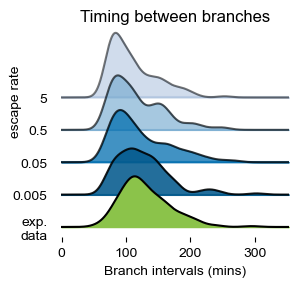

In [28]:
plot.vary_lambda('sfig5mp', 'MO', 0.1)
plot.ridge_plot('sfig5mp', 'P', 'lambda', 50)

# SI Figure 6:

## A-C

In [29]:
config = {
    'seeds': 50,
    'loop_type': 'startN',
    'loop_values': [40, 60, 80, 100],
    'options': {
        ###############################
        # 'tip_splits': 'random',
        # 'tip_splits': 'all_random',
        'tip_splits': 'triggered',
        ###############################
        # 'frequencies': 'random',
        'frequencies': 'G1_exit',
        ###############################
        ### optional, include to override defaults:
        # 'N': 5000,         # default: 8000
        # 'D': 0.02,         # default: 0
        # 'w_std': 0,        # default: 40
        'w_mean': 110,     # default: 120
        # 'lambda': 0.005,    # default 0.05
        # 'beta': 0.02,      # default 0.03
    }
}

data = run_model(config, save_as='sfig6ac.pkl')

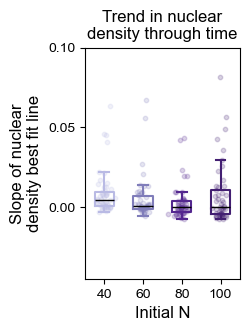

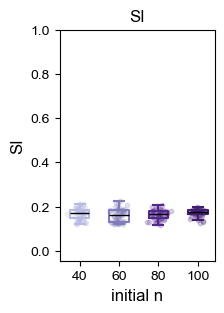

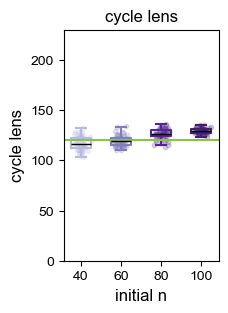

In [30]:
plot.vary_N('sfig6ac', 'AC', 0.1, False)

## D-F

In [31]:
config = {
    'seeds': 50,
    'loop_type': 'startN',
    'loop_values': [40, 60, 80, 100],
    'options': {
        ###############################
        # 'tip_splits': 'random',
        # 'tip_splits': 'all_random',
        'tip_splits': 'triggered',
        ###############################
        # 'frequencies': 'random',
        'frequencies': 'G1_exit',
        ###############################
        ### optional, include to override defaults:
        # 'N': 5000,         # default: 8000
        # 'D': 0.02,         # default: 0
        # 'w_std': 0,        # default: 40
        'w_mean': 100,     # default: 120
        # 'lambda': 0.005,    # default 0.05
        # 'beta': 0.02,      # default 0.03
    }
}

data = run_model(config, save_as='sfig6df.pkl')

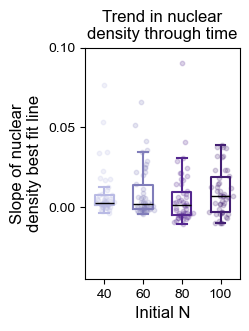

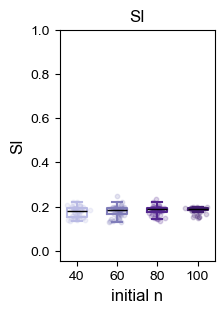

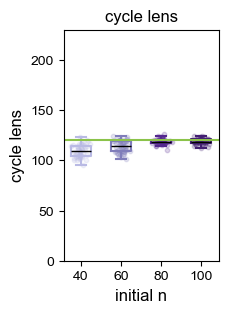

In [32]:
plot.vary_N('sfig6df', 'DF', 0.1, False)